In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [45]:
df=pd.read_csv('cs-training.csv',index_col=0)

In [46]:
df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 150000 entries, 1 to 150000
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non-null  float64
dtype

In [48]:
df.shape

(150000, 11)

In [49]:
df.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


In [50]:
missing_values=df.isnull().sum()

In [51]:
df['MonthlyIncome'] = df['MonthlyIncome'].fillna(df['MonthlyIncome'].median())

In [52]:
df['NumberOfDependents']=df['NumberOfDependents'].fillna(df['NumberOfDependents'].median())

In [53]:
df.isnull().sum()

SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
dtype: int64

In [54]:
print("age max:",df['age'].max())

age max: 109


In [55]:
print("age min:",df['age'].min())

age min: 0


In [56]:
print("RevolvingUtilizationOfUnsecuredLines max :",df['RevolvingUtilizationOfUnsecuredLines'].max())

RevolvingUtilizationOfUnsecuredLines max : 50708.0


In [57]:
print("DebtRatio max:",df['DebtRatio'].max())

DebtRatio max: 329664.0


In [58]:
# removing outliers
df=df[df['age'] > 0]

In [59]:
df=df[df['RevolvingUtilizationOfUnsecuredLines']<=1]

In [60]:
df=df[df['DebtRatio']<=1]

In [61]:
df.shape

(112262, 11)

In [62]:
150000 - df.shape[0]

37738

In [63]:
plt.figure(figsize=(8,5))

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

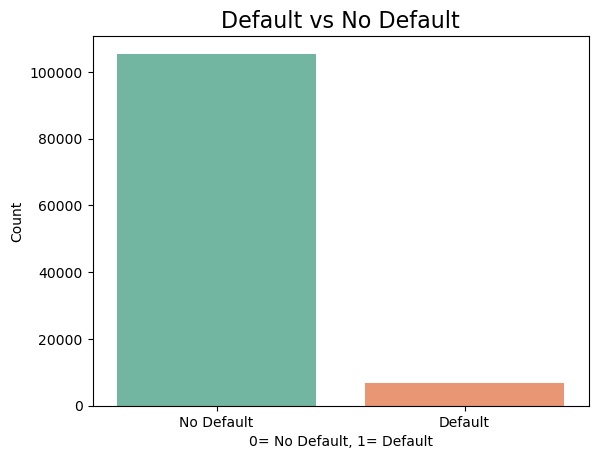

In [64]:
# DEDAULT vs NON DEFAULT
sns.countplot(x='SeriousDlqin2yrs',data=df,palette='Set2')
plt.title('Default vs No Default', fontsize=16)
plt.xlabel('0= No Default, 1= Default')
plt.ylabel('Count')
plt.xticks([0,1],['No Default','Default'])
plt.show()


In [65]:
df['SeriousDlqin2yrs'].value_counts()

0    105481
1      6781
Name: SeriousDlqin2yrs, dtype: int64

In [66]:
df['SeriousDlqin2yrs'].mean()*100

6.040334218168213

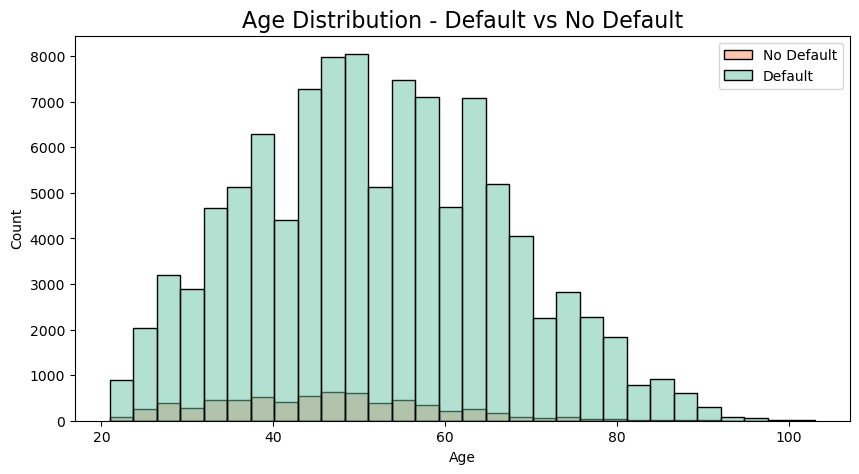

In [67]:
# AGE DISTRIBUTION
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='age', hue='SeriousDlqin2yrs', 
             bins=30, palette='Set2')
plt.title('Age Distribution - Default vs No Default', fontsize=16)
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend(['No Default', 'Default'])
plt.show()

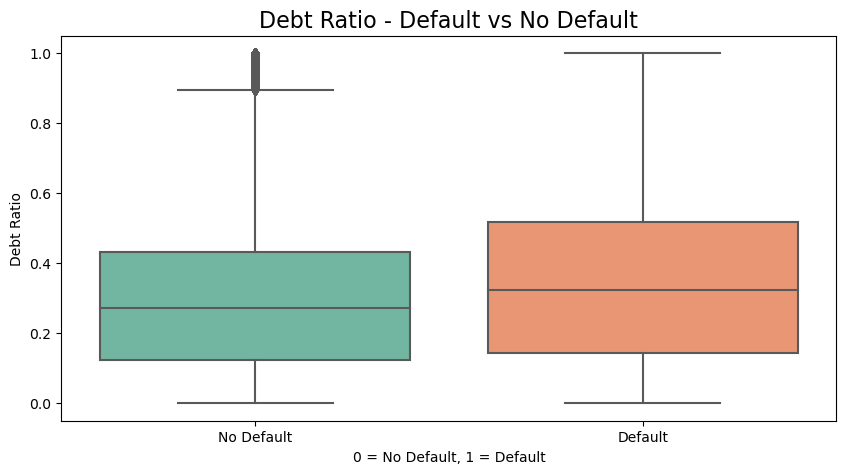

In [68]:
# DEBT RATIO vs DEFAULT
plt.figure(figsize=(10, 5))
sns.boxplot(x='SeriousDlqin2yrs', y='DebtRatio', 
            data=df, palette='Set2')
plt.title('Debt Ratio - Default vs No Default', fontsize=16)
plt.xlabel('0 = No Default, 1 = Default')
plt.ylabel('Debt Ratio')
plt.xticks([0, 1], ['No Default', 'Default'])
plt.show()


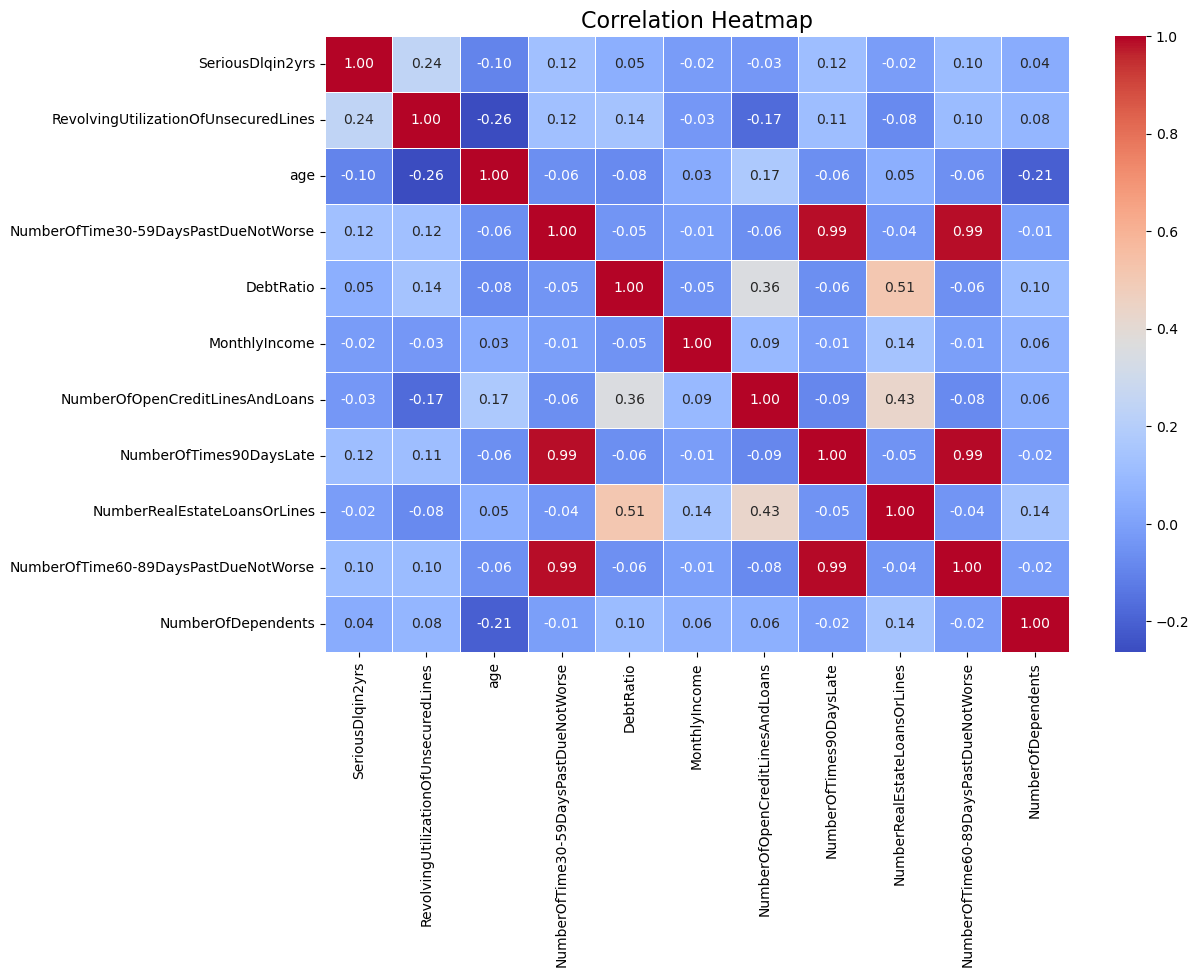

In [69]:
#CORRELATION HEAT
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', 
            cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=16)
plt.show()

In [70]:
df['IncomePerPerson'] = df['MonthlyIncome'] / (df['NumberOfDependents'] + 1)

In [71]:
df['TotalLatePayments'] = (df['NumberOfTime30-59DaysPastDueNotWorse']+
                           df['NumberOfTime60-89DaysPastDueNotWorse']+
                           df['NumberOfTimes90DaysLate'])

In [72]:
df['AgeGroup']=pd.cut(df['age'], bins=[0,30,45,60,100], labels=['young','middle','senior','old'])

In [73]:
(df[['IncomePerPerson','TotalLatePayments','AgeGroup']].head())

,IncomePerPerson,TotalLatePayments,AgeGroup
1,3040.0,2,middle
2,1300.0,0,middle
3,3042.0,2,middle
4,3300.0,0,young
5,63588.0,1,senior


In [74]:
age_default = df.groupby('AgeGroup')['SeriousDlqin2yrs'].mean() * 100
age_default.round(2)

AgeGroup
young     10.21
middle     7.95
senior     6.19
old        2.82
Name: SeriousDlqin2yrs, dtype: float64

In [75]:
late_default = df.groupby('TotalLatePayments')['SeriousDlqin2yrs'].mean() * 100
late_default.head(10).round(2)

TotalLatePayments
0     2.68
1    10.99
2    21.93
3    30.74
4    40.73
5    50.33
6    54.96
7    55.81
8    54.05
9    59.38
Name: SeriousDlqin2yrs, dtype: float64

In [76]:
income_default = df.groupby('SeriousDlqin2yrs')['MonthlyIncome'].mean()
income_default.round(2)

SeriousDlqin2yrs
0    7025.81
1    5966.78
Name: MonthlyIncome, dtype: float64

In [77]:
#clean dataset
df.to_csv('cs_cleaned.csv', index= False)

In [78]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [79]:
df = pd.read_csv('cs_cleaned.csv')

In [80]:
df.shape

(112262, 14)

In [81]:
# drop columns
df = df.drop(['AgeGroup'],axis=1)

In [82]:
# seperate features and target
x = df.drop('SeriousDlqin2yrs', axis=1)
y = df['SeriousDlqin2yrs']

In [83]:
print("x shape :",x.shape)
print("y shape :",y.shape)

x shape : (112262, 12)
y shape : (112262,)


In [84]:
x.columns.tolist()

['RevolvingUtilizationOfUnsecuredLines',
 'age',
 'NumberOfTime30-59DaysPastDueNotWorse',
 'DebtRatio',
 'MonthlyIncome',
 'NumberOfOpenCreditLinesAndLoans',
 'NumberOfTimes90DaysLate',
 'NumberRealEstateLoansOrLines',
 'NumberOfTime60-89DaysPastDueNotWorse',
 'NumberOfDependents',
 'IncomePerPerson',
 'TotalLatePayments']

In [85]:
x_train ,x_test ,y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)
print("training size :",x_train.shape)
print("testing:", x_test.shape)

training size : (89809, 12)
testing: (22453, 12)


In [86]:
# Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state= 42)
lr_model.fit(x_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [87]:
# Predict on test data
lr_predict = lr_model.predict(x_test)

In [88]:
lr_accuracy = accuracy_score(y_test, lr_predict)
print("LogisticRegression Accuracy:",round(lr_accuracy * 100, 2),"%")
classification_report(y_test, lr_predict)


LogisticRegression Accuracy: 93.89 %


'              precision    recall  f1-score   support\n\n           0       0.94      1.00      0.97     21075\n           1       0.52      0.05      0.09      1378\n\n    accuracy                           0.94     22453\n   macro avg       0.73      0.52      0.53     22453\nweighted avg       0.92      0.94      0.91     22453\n'

In [ ]:
# Random Forest with class_weight balanced
rf_model = RandomForestClassifier(n_estimators=100,class_weight='balanced',random_state=42)

rf_model.fit(x_train, y_train)
rf_pred = rf_model.predict(x_test)

rf_accuracy = accuracy_score(y_test, rf_pred)
print("Random Forest Accuracy:", round(rf_accuracy * 100, 2), "%")

print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 93.87 %
              precision    recall  f1-score   support

           0       0.95      0.99      0.97     21075
           1       0.50      0.12      0.20      1378

    accuracy                           0.94     22453
   macro avg       0.72      0.56      0.58     22453
weighted avg       0.92      0.94      0.92     22453



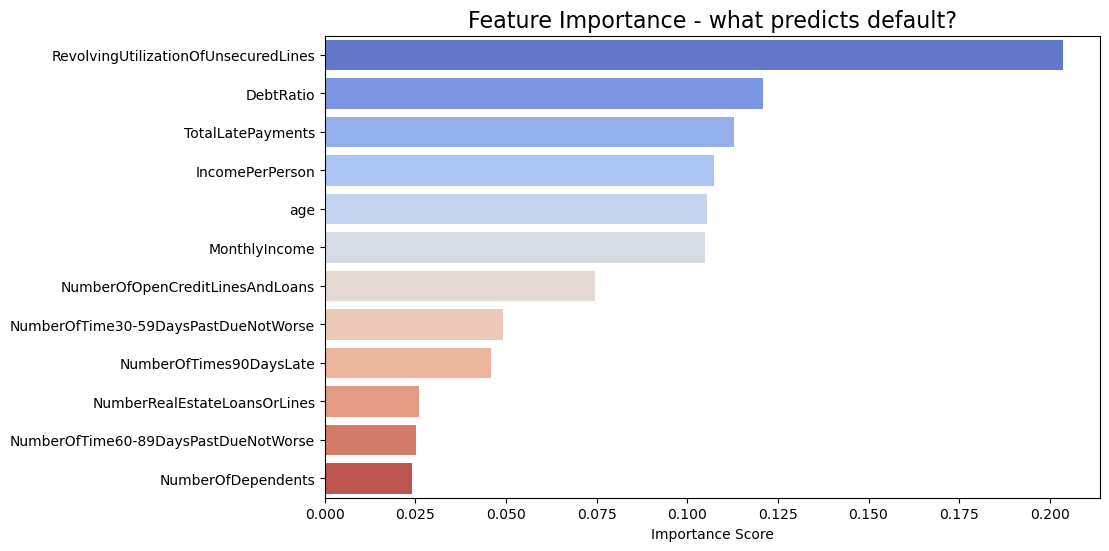

In [91]:
# Feature importance chart
importance = pd.Series(rf_model.feature_importances_ , index= x.columns)
importance = importance.sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=importance.values, y=importance.index, palette='coolwarm')
plt.title('Feature Importance - what predicts default?', fontsize=16)
plt.xlabel('Importance Score')
plt.show()


In [93]:
print(""" 
BUSINESS INSIGHTS & RECOMMENDATION
    BANK LOAN DEFAULT - PROJECT SUMMARY
      WHAT I FOUND:
     -----------------------
- Only 6% of customers actually defaulted
- Young customers (under 30) default the most - almost 10%
- The more late payments a person has, the higher their risk
- Defaulters earn about 15% less income on average
- Credit card usage % is the #1 sign someone will default
      
    MY ENGINEERED FEATURES:
    -----------------------
- TotalLatePayments : combined all overdue columns into one
- IncomePerPerson   : income divided by dependents
- Both ranked in top 4 most important features
      
    MODEL RESULTS:
    --------------
- Logistic Regression : 93.89% accuracy
- Random Forest       : 93.87% accuracy
- Dataset was imbalanced (94% non-defaulters)
- This can be improved with SMOTE in future
      
    MY RECOMMENDATIONS TO THE BANK:
--------------------------------
- Be careful with customers under 30 years old
- Reject or review loans if utilization is above 70%
- Anyone with 3+ late payments is high risk
- Lower income customers need smaller loan limits
      
 """)

 
BUSINESS INSIGHTS & RECOMMENDATION
    BANK LOAN DEFAULT - PROJECT SUMMARY
      WHAT I FOUND:
     -----------------------
- Only 6% of customers actually defaulted
- Young customers (under 30) default the most - almost 10%
- The more late payments a person has, the higher their risk
- Defaulters earn about 15% less income on average
- Credit card usage % is the #1 sign someone will default
      
    MY ENGINEERED FEATURES:
    -----------------------
- TotalLatePayments : combined all overdue columns into one
- IncomePerPerson   : income divided by dependents
- Both ranked in top 4 most important features
      
    MODEL RESULTS:
    --------------
- Logistic Regression : 93.89% accuracy
- Random Forest       : 93.87% accuracy
- Dataset was imbalanced (94% non-defaulters)
- This can be improved with SMOTE in future
      
    MY RECOMMENDATIONS TO THE BANK:
--------------------------------
- Be careful with customers under 30 years old
- Reject or review loans if utilization is a